Ejercicio 2: Análisis de Correlación

## Dataset: `clave_F_correlacion.csv`

## Paso 1. Importación de librerías

In [1]:
import os
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## Paso 2. Carga y exploración inicial del dataset

In [4]:
# Cargar el archivo CSV desde la carpeta local o extraerlo desde csv.zip si es necesario
url = "https://raw.githubusercontent.com/NixonAV/Parcial4AyalaNixon2509112022/refs/heads/main/Archivos/clave_F_correlacion.csv"

df = pd.read_csv(url, encoding="utf-8-sig")

print("Dimensiones del dataset:", df.shape)
df.head(10)

Dimensiones del dataset: (246, 10)


,cliente_id,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
0,F-C0001,18,1184,6,63.55,7.05,1,2,20.42,344.76
1,F-C0002,32,1023,8,60.06,7.88,2,7,12.99,475.57
2,F-C0003,46,1231,9,61.11,7.22,1,5,23.16,554.42
3,F-C0004,48,783,4,37.37,5.69,4,4,26.98,233.89
4,F-C0005,31,1187,7,65.26,3.50,8,7,28.48,386.42
5,F-C0006,45,667,9,38.08,8.24,1,7,29.87,430.45
6,F-C0007,37,1144,6,68.62,5.77,4,6,27.91,427.75
7,F-C0008,37,1367,7,77.70,5.14,5,4,31.62,552.23
8,F-C0009,35,1269,8,45.69,7.45,1,7,16.79,462.70
9,F-C0010,37,1184,11,82.26,6.87,4,8,16.66,804.66


In [5]:
print("Tipos de datos:")
print(df.dtypes)
print("\nValores nulos por columna:")
print(df.isnull().sum())
print("\nRegistros duplicados:", df.duplicated().sum())

print("\nVariables numéricas identificadas:")
num_cols = df.select_dtypes(include='number').columns.tolist()
print(num_cols)

Tipos de datos:
cliente_id             object
edad                    int64
ingresos_mensuales      int64
frecuencia_compra       int64
ticket_promedio       float64
satisfaccion          float64
reclamos                int64
uso_app                 int64
tiempo_respuesta      float64
consumo_total         float64
dtype: object

Valores nulos por columna:
cliente_id            0
edad                  0
ingresos_mensuales    0
frecuencia_compra     0
ticket_promedio       1
satisfaccion          1
reclamos              0
uso_app               0
tiempo_respuesta      1
consumo_total         0
dtype: int64

Registros duplicados: 1

Variables numéricas identificadas:
['edad', 'ingresos_mensuales', 'frecuencia_compra', 'ticket_promedio', 'satisfaccion', 'reclamos', 'uso_app', 'tiempo_respuesta', 'consumo_total']


## Paso 3. Revisión de calidad de datos

In [6]:
# Resumen estadístico
resumen = df[num_cols].describe().T
resumen['rango'] = resumen['max'] - resumen['min']
resumen

,count,mean,std,min,25%,50%,75%,max,rango
edad,246.0,38.796748,10.220395,18.00,31.0000,39.00,46.0000,62.00,44.00
ingresos_mensuales,246.0,1117.601626,265.006700,484.00,924.5000,1115.50,1297.5000,1838.00,1354.00
frecuencia_compra,246.0,7.906504,3.288104,2.00,6.0000,8.00,9.0000,32.00,30.00
ticket_promedio,245.0,66.171633,15.495566,27.13,56.1800,66.02,75.9500,114.02,86.89
satisfaccion,245.0,7.529551,1.340410,3.02,6.7900,7.75,8.5100,10.00,6.98
reclamos,246.0,1.536585,1.748668,0.00,0.0000,1.00,2.0000,9.00,9.00
uso_app,246.0,5.642276,2.068737,0.00,4.0000,6.00,7.0000,10.00,10.00
tiempo_respuesta,245.0,21.083388,6.751156,5.00,16.6000,20.55,25.5100,43.50,38.50
consumo_total,246.0,524.573943,223.164093,145.72,378.1775,514.65,627.7375,2026.66,1880.94


In [7]:
# Revisión de valores atípicos con criterio IQR
outlier_data = []
for c in num_cols:
    q1 = df[c].quantile(0.25)
    q3 = df[c].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    n_out = int(((df[c] < lim_inf) | (df[c] > lim_sup)).sum())
    outlier_data.append({
        'variable': c,
        'limite_inferior': round(lim_inf, 3),
        'limite_superior': round(lim_sup, 3),
        'atipicos': n_out
    })

outliers_df = pd.DataFrame(outlier_data)
outliers_df

,variable,limite_inferior,limite_superior,atipicos
0,edad,8.500,68.500,0
1,ingresos_mensuales,365.000,1857.000,0
2,frecuencia_compra,1.500,13.500,3
3,ticket_promedio,26.525,105.605,2
4,satisfaccion,4.210,11.090,4
5,reclamos,-3.000,5.000,8
6,uso_app,-0.500,11.500,0
7,tiempo_respuesta,3.235,38.875,4
8,consumo_total,3.838,1002.077,4


## Paso 4. Matriz de correlación

In [8]:
corr = df[num_cols].corr()

# Mostrar la matriz redondeada
corr.round(3)

,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
edad,1.000,0.070,0.074,0.139,-0.016,0.046,0.062,0.019,0.097
ingresos_mensuales,0.070,1.000,0.066,0.665,-0.059,0.006,-0.045,0.165,0.323
frecuencia_compra,0.074,0.066,1.000,0.169,0.127,-0.069,0.401,-0.082,0.896
ticket_promedio,0.139,0.665,0.169,1.000,-0.031,-0.008,-0.006,0.068,0.527
satisfaccion,-0.016,-0.059,0.127,-0.031,1.000,-0.829,0.245,-0.620,0.180
reclamos,0.046,0.006,-0.069,-0.008,-0.829,1.000,-0.021,0.616,-0.141
uso_app,0.062,-0.045,0.401,-0.006,0.245,-0.021,1.000,-0.209,0.393
tiempo_respuesta,0.019,0.165,-0.082,0.068,-0.620,0.616,-0.209,1.000,-0.117
consumo_total,0.097,0.323,0.896,0.527,0.180,-0.141,0.393,-0.117,1.000


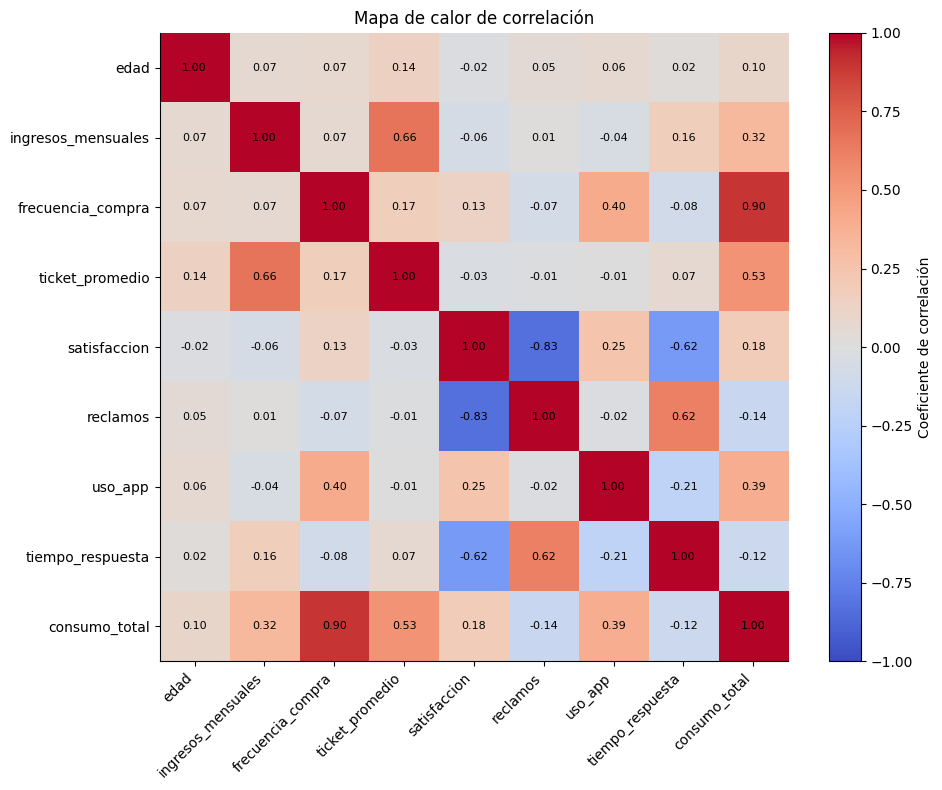

In [9]:
# Mapa de calor con matplotlib
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha='right')
ax.set_yticklabels(num_cols)

for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Coeficiente de correlación')
ax.set_title('Mapa de calor de correlación')
plt.tight_layout()
plt.show()

## Paso 5. Correlaciones positivas y negativas más importantes

In [10]:
# Pares únicos de correlación
pairs = []
for i in range(len(num_cols)):
    for j in range(i + 1, len(num_cols)):
        pairs.append((num_cols[i], num_cols[j], corr.iloc[i, j]))

top_positivas = sorted(pairs, key=lambda x: x[2], reverse=True)[:5]
top_negativas = sorted(pairs, key=lambda x: x[2])[:5]

print("Top 5 correlaciones positivas:")
for a, b, r in top_positivas:
    print(f"- {a} vs {b}: r = {r:.3f}")

print("\nTop 5 correlaciones negativas:")
for a, b, r in top_negativas:
    print(f"- {a} vs {b}: r = {r:.3f}")

Top 5 correlaciones positivas:
- frecuencia_compra vs consumo_total: r = 0.896
- ingresos_mensuales vs ticket_promedio: r = 0.665
- reclamos vs tiempo_respuesta: r = 0.616
- ticket_promedio vs consumo_total: r = 0.527
- frecuencia_compra vs uso_app: r = 0.401

Top 5 correlaciones negativas:
- satisfaccion vs reclamos: r = -0.829
- satisfaccion vs tiempo_respuesta: r = -0.620
- uso_app vs tiempo_respuesta: r = -0.209
- reclamos vs consumo_total: r = -0.141
- tiempo_respuesta vs consumo_total: r = -0.117


In [11]:
# Tabla de correlaciones más relevantes por valor absoluto
corr_pairs = pd.DataFrame(pairs, columns=['variable_1', 'variable_2', 'correlacion'])
corr_pairs['abs_correlacion'] = corr_pairs['correlacion'].abs()
corr_pairs = corr_pairs.sort_values('abs_correlacion', ascending=False)

corr_pairs.head(10)

,variable_1,variable_2,correlacion,abs_correlacion
20,frecuencia_compra,consumo_total,0.896130,0.896130
26,satisfaccion,reclamos,-0.829036,0.829036
9,ingresos_mensuales,ticket_promedio,0.664902,0.664902
28,satisfaccion,tiempo_respuesta,-0.620456,0.620456
31,reclamos,tiempo_respuesta,0.616314,0.616314
25,ticket_promedio,consumo_total,0.526827,0.526827
18,frecuencia_compra,uso_app,0.401293,0.401293
34,uso_app,consumo_total,0.392901,0.392901
14,ingresos_mensuales,consumo_total,0.322528,0.322528
27,satisfaccion,uso_app,0.245222,0.245222


## Paso 6. Interpretación de resultados

1. Existe una correlación muy alta y positiva entre **frecuencia_compra** y **consumo_total** (r = 0.896), lo que indica que cuando el cliente compra con más frecuencia, su gasto acumulado tiende a crecer.
2. **Ingresos_mensuales** y **ticket_promedio** presentan una correlación positiva fuerte (r = 0.665); esto sugiere que los clientes con mayor ingreso suelen realizar compras de mayor valor.
3. Se observa una relación positiva moderada entre **reclamos** y **tiempo_respuesta** (r = 0.616); esto puede reflejar que, cuando la atención tarda más, aumentan los reclamos.
4. La relación negativa más importante está entre **satisfaccion** y **reclamos** (r = -0.829), por lo que más reclamos se asocian con menor satisfacción del cliente.

**Conclusión:** En conjunto, estas relaciones ayudan a la empresa a identificar qué variables impactan directamente en la experiencia del cliente. Por ejemplo, reducir el tiempo de respuesta y los reclamos puede elevar la satisfacción, mientras que impulsar la frecuencia de compra y mejorar el uso de la aplicación puede aumentar el consumo total.

En términos de negocio, la empresa puede usar estas relaciones para priorizar acciones sobre servicio al cliente, tiempos de respuesta, promoción del uso de la aplicación y estrategias para aumentar frecuencia de compra y valor del ticket.